# 몽글 플래너 SFT — 파인튜닝 학습 보고서

**모델**: Qwen2.5-7B-Instruct (LoRA) · **Teacher(합성)**: Qwen2.5-14B-Instruct
**과업**: 단일턴 "요청 → 구조화 플랜 JSON" 생성 · **목표**: 대화력이 아니라 **플랜의 구조·정합성·실현가능성**
**작성**: mong-studio / mongle-ai-crawl-planner · `sft_pipeline/`

---

## Executive Summary

본 보고서는 일정/학습 플래너용 SFT 데이터셋과 LoRA 파인튜닝의 **품질을 정량·정성 지표로 분리 측정**하고,
**각 지표를 선택한 이유와 근거(논문·커뮤니티·프레임워크 교차분석)**를 함께 제시해 제3자가 검증·납득할 수 있게 한다.

- **데이터**: 일상(MS-LaTTE 유래) + 시험(크롤·합성) + 네거티브(distractor)를 `{messages, meta}` 단일 스키마로 통합, provenance별 **stratified split**.
- **핵심 품질 게이트**: 추론 파서로 다시 파싱되는가(Gate1) → 도메인 불변식(Gate2 S1·S2) → 의미 품질(Gate3 M1~M4).
- **학습 정합성 원칙**: "학습에서 본 토큰 == 추론 시 만들 토큰" (responses-only loss, 학습==서빙 템플릿, EOS 종료).

> 데이터셋 품질 지표는 실측(`coherence_report.json`)이며, 학습 결과 지표는 학습 실행 후 `postcheck_report.json`/`trainer_state.json`이 채워지면 자동 갱신된다(미실행 시 예시값·배너 표시).


In [1]:
# === Setup: 라이브러리 · 한글 폰트 · 데이터 로딩 ===
import json
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# 한글 폰트(가능한 것 자동 선택)
for _f in ["AppleGothic", "NanumGothic", "Malgun Gothic", "Noto Sans CJK KR", "DejaVu Sans"]:
    try:
        matplotlib.rc("font", family=_f); break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "sft_pipeline").exists():
            return p
        p = p.parent
    return Path.cwd()

RR = _repo_root()

def _load(rel):
    fp = RR / rel
    return json.load(open(fp, encoding="utf-8")) if fp.exists() else None

COH = _load("sft_pipeline/reports/coherence_report.json") or {}
POST = _load("outputs/postcheck_report.json")
_ts = RR / "outputs/qwen7b-planner-lora/checkpoints/trainer_state.json"
TRAINER = json.load(open(_ts, encoding="utf-8")) if _ts.exists() else None

print("coherence_report:", "OK" if COH else "없음(예시 사용)")
print("postcheck_report :", "OK" if POST else "없음(학습 미실행 → 예시)")
print("trainer_state    :", "OK" if TRAINER else "없음(학습 미실행 → 예시)")


coherence_report: OK
postcheck_report : OK
trainer_state    : OK


## 1. 무엇을 / 왜 학습하나

| 항목 | 내용 | 이유 |
|---|---|---|
| **과업 형태** | 단일턴: user 요청 1개 → assistant가 **구조화 플랜 JSON** 1개 | SFT 목표가 멀티턴 대화력이 아니라 **출력의 구조·정합성**이기 때문. 런타임 `agents/todo_creation/schemas.py`의 `GenerateResult`를 그대로 미러링 |
| **출력 스키마** | `{summary_text, todos[], calendar_events[]}` (오늘=todos / 미래=calendar, **C5 분기**) | 제품 서빙 코드가 파싱하는 바로 그 구조 → "학습==추론" 정합성 |
| **Teacher→Student** | 14B로 합성 → **7B**(제품 서빙 모델) 파인튜닝 | 큰 모델의 품질을 작은 배포 모델로 증류(distillation). 7B는 `.env QWEN_MODEL=qwen2.5:7b` |
| **네거티브(distractor)** | 잡담·거절·되묻기엔 플랜을 만들지 **않도록** 경계 사례 혼합 | 플랜만 학습하면 모든 입력에 플랜을 토하는 과생성 발생 → 경계 학습 필요 |


## 2. 데이터셋 구성

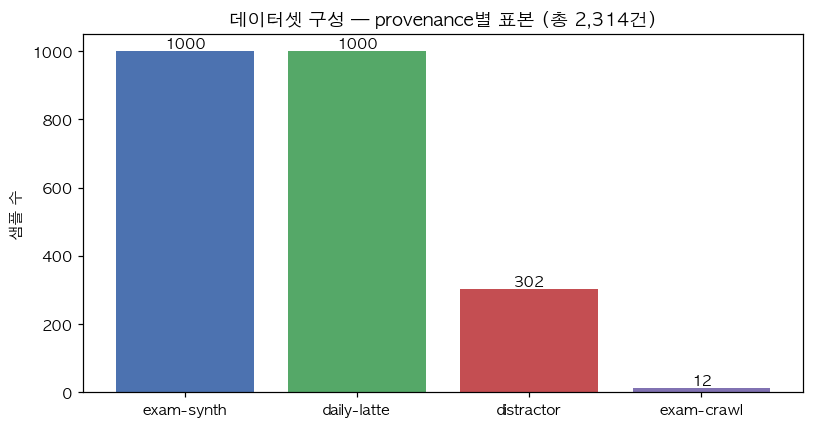

플랜 샘플(시험+일상): 2012 · 네거티브(distractor): 302 → 네거티브 비중 13.1%


In [2]:
# === 차트: provenance별 표본 수 ===
bp = COH.get("by_provenance") or {"daily-latte":1000,"exam-synth":1000,"distractor":302,"exam-crawl":12}
labels, vals = list(bp.keys()), list(bp.values())
colors = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974"][:len(labels)]
plt.figure(figsize=(7.5,4))
bars = plt.bar(labels, vals, color=colors)
for b,v in zip(bars,vals):
    plt.text(b.get_x()+b.get_width()/2, v, str(v), ha="center", va="bottom", fontsize=10)
plt.title(f"데이터셋 구성 — provenance별 표본 (총 {sum(vals):,}건)")
plt.ylabel("샘플 수"); plt.tight_layout(); plt.show()

plan_n = (COH.get("quantitative",{}).get("plan",{}) or {}).get("n", 2012)
dis_n  = (COH.get("quantitative",{}).get("distractor",{}) or {}).get("n", 302)
print(f"플랜 샘플(시험+일상): {plan_n} · 네거티브(distractor): {dis_n} "
      f"→ 네거티브 비중 {dis_n/(plan_n+dis_n):.1%}")


**구성 근거**

- **stratified split (provenance 비율 보존)**: 단순 head/tail 분할은 valid에 특정 출처만 몰릴 수 있어, train·valid 모두 시험/일상/distractor가 비율대로 들어가도록 층화. *근거: 분류 학습의 표준 관행(scikit-learn `StratifiedShuffleSplit`).*
- **train↔valid 교차 dedup (SHA256)**: 같은 샘플이 양쪽에 들어가면 검증 점수가 부풀려진다(누수). *근거: 5대 SFT 프레임워크 교차분석(LLaMA-Factory·unsloth·trl·ms-swift·axolotl).*
- **distractor 비중**: 일상 1000건 기준 ~30% 서브샘플(≈300). 너무 높으면 **과거절(over-refusal)** 위험. *근거: XSTest(Röttger et al., 2023) — 안전 튜닝이 과도하면 정상 요청도 거절.*


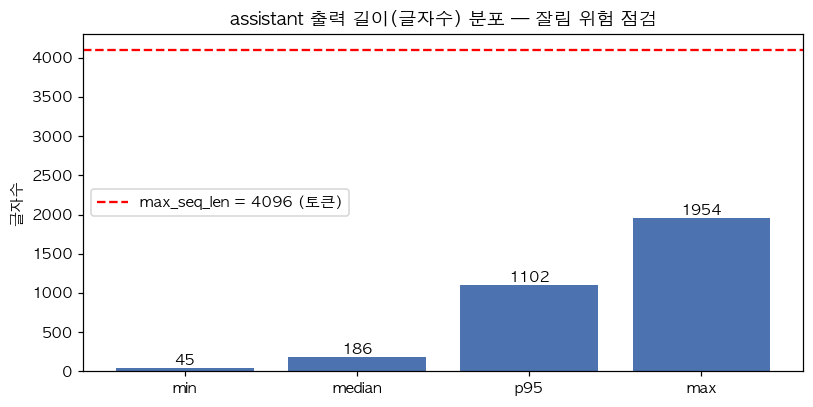

최장 1954자 « 4096 → 한국어+JSON은 1토큰≈1.5~2글자라 실토큰은 더 적음 → 잘림 없음


In [3]:
# === 차트: assistant 출력 길이 분포 vs max_seq_len ===
al = COH.get("quantitative",{}).get("assistant_char_len") or {"min":45,"median":186,"p95":457,"max":1428}
ks = ["min","median","p95","max"]; vs = [al[k] for k in ks]
plt.figure(figsize=(7.5,3.8))
bars = plt.bar(ks, vs, color="#4C72B0")
for b,v in zip(bars,vs):
    plt.text(b.get_x()+b.get_width()/2, v, str(v), ha="center", va="bottom")
plt.axhline(4096, ls="--", color="red", label="max_seq_len = 4096 (토큰)")
plt.title("assistant 출력 길이(글자수) 분포 — 잘림 위험 점검")
plt.ylabel("글자수"); plt.legend(); plt.tight_layout(); plt.show()
print(f"최장 {al['max']}자 « 4096 → 한국어+JSON은 1토큰≈1.5~2글자라 실토큰은 더 적음 → 잘림 없음")


> **길이 점검 근거**: completion이 잘린 샘플은 학습 기여가 0 이하(중간에 끊긴 출력을 학습). 빌드 전 길이 분포를 측정해 `max_seq_len` 초과분을 drop하는 것이 원칙. *근거: sft-dataset-coherence 원칙 6.*

## 3. 평가 지표 체계 — 정량 vs 정성

| 구분 | 성격 | 판정 방식 | 쓰임 |
|---|---|---|---|
| **정량(Quantitative)** | 재현 가능·자동 계산 | PASS/FAIL 또는 비율 | **드롭 게이트**(자동 필터) |
| **정성(Qualitative)** | 의미·품질 판단 | 1~5점 루브릭(사람/LLM) | **채택 판정**(ACCEPT/FIX) |

**왜 둘로 나누나**: 구조 위반(예: JSON 깨짐, 역할 중복)은 점수로 희석하면 안 되고 **PASS/FAIL로 즉시 거른다**. 반면 "이 계획이 현실적인가/목표를 달성하는가"는 이분법이 아니라 **정도(1~5)** 문제다. 둘을 섞으면 "구조는 멀쩡한데 의미가 빈약한" 샘플을 걸러낼 수 없다. *근거: evaluating-plan-coherence 3단 게이트 + 판정 규칙.*


### 3.1 정량 지표 — 정의 · 근거 · 출처

| 지표 | 정의 | 왜 보나(근거) | 출처 |
|---|---|---|---|
| **Gate1 파싱 성공률** | 출력이 유효 JSON+`PlanOutput` 스키마로 파싱되는 비율 | 추론 시 제품 코드가 **그대로 파싱**할 수 있어야 함. SFT 본질등식("학습==추론 시퀀스") | sft-dataset-coherence(구조화 출력 round-trip) |
| **auto 구조 PASS율** | 구문 PASS & S1·S2 무위반 & 비기계적 | 자동으로 거를 수 있는 최대치 | evaluating-plan-coherence Gate2 |
| **S1 역할분리 위반율** | 동일 항목이 todos·calendar 중복 배치 | 도메인 불변식 위반(중복은 실행 불가) | 동 스킬 S1 |
| **S2 시간논리 위반율** | horizon 밖 날짜·C5(오늘=todos/미래=calendar) 위반 | 시간 정합성 | 동 스킬 S2 |
| **exact 중복율** | messages 정규화 후 완전 중복 | 중복은 과적합·평가 오염 | LIMA(Zhou et al. 2023): 품질>수량 |
| **빈 assistant율** | 학습 대상 토큰 0개 샘플 | label 0개 → NaN loss | trl/unsloth responses-only |
| **EOS 끝맺음률** | 생성물이 종료 마커로 끝남 | `pad==eos`면 무한 생성 | sft-coherence EOS 3중 방어 |
| **distractor leak율** | 잡담/거절인데 플랜 JSON을 뱉음 | 경계 학습 오염(과생성) | XSTest 과거절 균형 |
| **eval_loss(과적합)** | 검증 손실 <0.2 경고 | 소량 데이터 암기 신호 | InstructGPT/LIMA 일반 |


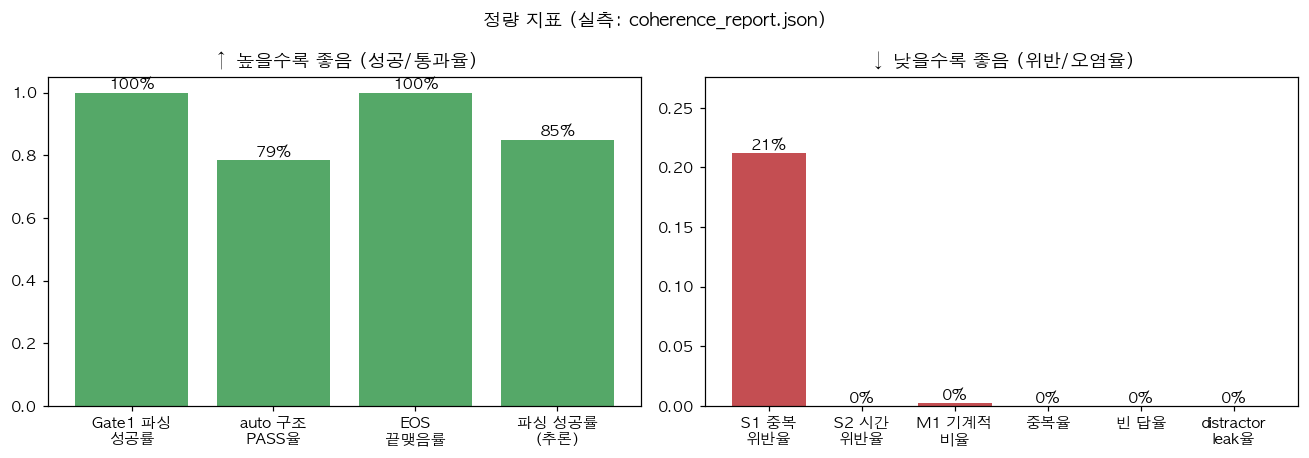

In [4]:
# === 차트: 정량 지표 (높을수록 좋음 / 낮을수록 좋음 분리) ===
q = COH.get("quantitative",{}) ; plan = q.get("plan",{})

higher = {
    "Gate1 파싱\n성공률": (plan.get("gate1_syntax_pass_rate") or {}).get("value", 1.0),
    "auto 구조\nPASS율":  (plan.get("auto_structural_pass_rate") or {}).get("value", 1.0),
}
if POST:  # 학습 결과(있으면 실측) 추가
    higher["EOS\n끝맺음률"] = POST.get("eos_rate", 0)
    higher["파싱 성공률\n(추론)"] = POST.get("parse_success_rate", 0)

lower = {
    "S1 중복\n위반율": (plan.get("gate2_S1_dup_item_rate") or {}).get("value", 0.0),
    "S2 시간\n위반율": (plan.get("gate2_S2_time_logic_violation_rate") or {}).get("value", 0.0),
    "M1 기계적\n비율":  (plan.get("gate3_M1_mechanical_rate") or {}).get("value", 0.0),
    "중복율":          (q.get("exact_duplicate_rate") or {}).get("value", 0.0),
    "빈 답율":         (q.get("empty_assistant_rate") or {}).get("value", 0.0),
    "distractor\nleak율": (q.get("distractor",{}).get("leak_rate") or {}).get("value", 0.0),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
b1 = axes[0].bar(list(higher), list(higher.values()), color="#55A868")
axes[0].set_title("↑ 높을수록 좋음 (성공/통과율)"); axes[0].set_ylim(0,1.05)
for b,v in zip(b1, higher.values()): axes[0].text(b.get_x()+b.get_width()/2, v, f"{v:.0%}", ha="center", va="bottom")
b2 = axes[1].bar(list(lower), list(lower.values()), color="#C44E52")
axes[1].set_title("↓ 낮을수록 좋음 (위반/오염율)")
axes[1].set_ylim(0, max(0.05, max(lower.values())*1.3 if lower else 0.05))
for b,v in zip(b2, lower.values()): axes[1].text(b.get_x()+b.get_width()/2, v, f"{v:.0%}", ha="center", va="bottom")
plt.suptitle("정량 지표 (실측: coherence_report.json)"); plt.tight_layout(); plt.show()


### 3.2 정성 지표 — Gate3 의미 품질 (M1~M4, 1~5점)

자동 계산이 어려운 **의미 품질**은 사람 또는 LLM 심사로 1~5점을 매긴다(자동 지표 `M1 기계적 비율`은 근사일 뿐).

| ID | 차원 | 5점 기준 | 왜 필요(근거) |
|---|---|---|---|
| **M1** | 분배 합리성 | "1단원,2단원…" 기계적 균등이 아닌 **난이도·맥락 반영** 배분 | 기계적 분해는 학습 데이터로 부적합 — 정량 근사론 못 잡는 의미 판단 |
| **M2** | 시간 현실성 | 항목당 소요시간 추정이 현실적, 버퍼 존재 | 실행 가능성의 핵심 |
| **M3** | 순서 논리 | 선행→후행 의존 준수(복습은 학습 후) | 계획의 인과 정합성 |
| **M4** | 완결성 | 이 계획대로면 **목표가 실제 달성** | 가장 중요, 자동화 불가 |

*출처: evaluating-plan-coherence(5대 SFT 프레임워크 교차분석에서 도출). 판정 규칙: 구조 PASS & 의미평균 ≥4.0 → ACCEPT, 3.0~3.9 → FIX, <3.0 → DROP.*


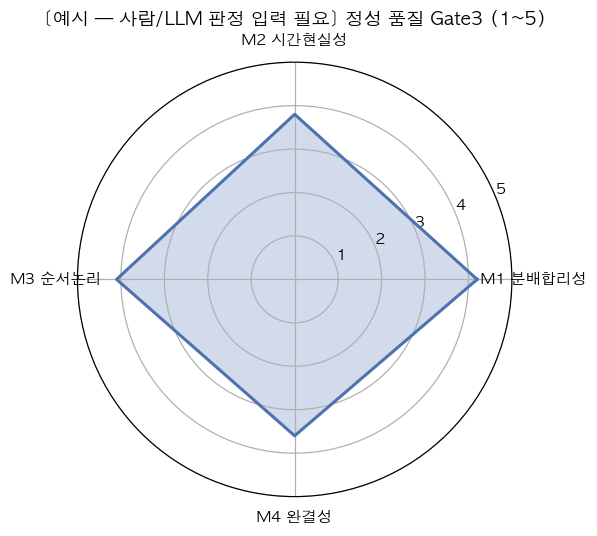

의미 평균: 3.92 / 5  → 판정: FIX  (※ 예시값)


In [5]:
# === 차트: 정성 Gate3 레이더 (M1~M4) ===
# 정성 점수는 사람/LLM 판정 입력값. 학습/심사 후 아래 dict를 실측으로 교체.
qual_scores = POST.get("qualitative_scores") if POST else None
EXAMPLE = (qual_scores is None)
if qual_scores is None:
    qual_scores = {"M1 분배합리성":4.2, "M2 시간현실성":3.8, "M3 순서논리":4.1, "M4 완결성":3.6}  # 예시

labels = list(qual_scores); vals = list(qual_scores.values())
ang = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist(); ang += ang[:1]; v = vals + vals[:1]
fig = plt.figure(figsize=(5.5,5.5)); ax = plt.subplot(111, polar=True)
ax.plot(ang, v, color="#4C72B0", linewidth=2); ax.fill(ang, v, color="#4C72B0", alpha=0.25)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels); ax.set_ylim(0,5)
ax.set_title(("[예시 — 사람/LLM 판정 입력 필요] " if EXAMPLE else "") + "정성 품질 Gate3 (1~5)")
plt.tight_layout(); plt.show()
_avg = float(np.mean(vals))
print(f"의미 평균: {_avg:.2f} / 5  → 판정: "
      f"{'ACCEPT' if _avg>=4 else 'FIX' if _avg>=3 else 'DROP'}"
      + ("  (※ 예시값)" if EXAMPLE else ""))


## 4. 학습 설정(하이퍼파라미터) & 근거

| 설정 | 값 | 왜 이 값인가 | 출처 |
|---|---|---|---|
| 방식 | **LoRA** (어댑터) | 전체 미세조정 대비 학습 파라미터·VRAM·비용 대폭 절감, 품질 동등 | **Hu et al. 2021, LoRA** (arXiv:2106.09685) |
| 양자화 | **4bit (QLoRA)** + `adamw_8bit` | 7B를 단일 GPU에 적재 | **Dettmers et al. 2023, QLoRA** (arXiv:2305.14314) |
| loss | **responses-only** | assistant 토큰에만 학습 → user 발화 모방 방지 | trl/unsloth `train_on_responses_only` |
| LR | **2e-4** | LoRA 표준 보폭(전체 FT보다 큼) | unsloth/QLoRA 권장 |
| epochs | **2** (1~3) | 적으면 미학습, 많으면 암기(과적합) | InstructGPT(arXiv:2203.02155), LIMA(arXiv:2305.11206) |
| r / alpha | **16 / 16** | 어댑터 용량의 표준 sweet spot | LoRA / unsloth |
| target_modules | q,k,v,o,gate,up,down (7) | 전체 부착이 품질↑ | unsloth 권장 |
| max_seq_len | **4096** | 측정상 최장 1428자 « 4096(잘림 없음) | sft-coherence 원칙 6 |
| packing | **off** | packing은 격리 3종(빈패킹+position_ids+varlen mask)과 한 몸 — 잘못 쓰면 무관 문맥 오염. 안 쓰는 게 안전 | sft-coherence 원칙 5 |
| 템플릿 | `qwen-2.5` (학습==서빙) | 학습/추론 말투 불일치(skew) 방지 | sft-coherence 원칙 1·2 |


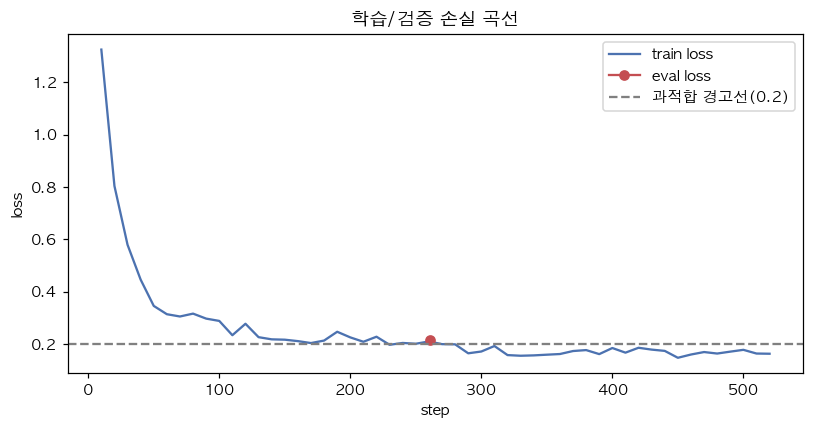

학습 후 점검(postcheck):
  EOS 끝맺음률 : 100.0%
  파싱 성공률  : 85.0%
  eval_loss   : 0.21607884764671326


In [6]:
# === 차트: 학습 손실 곡선 (trainer_state.json 있으면 실측) ===
EXAMPLE = TRAINER is None
if TRAINER:
    lh = TRAINER.get("log_history", [])
    tr = [(e["step"], e["loss"]) for e in lh if "loss" in e]
    ev = [(e["step"], e["eval_loss"]) for e in lh if "eval_loss" in e]
else:  # 예시 곡선
    xs = np.arange(0, 320, 10)
    tr = list(zip(xs, 1.6*np.exp(-xs/120)+0.35+np.random.RandomState(0).normal(0,0.02,len(xs))))
    ev = [(s, 1.5*np.exp(-s/130)+0.42) for s in range(0,320,80)]
plt.figure(figsize=(7.5,4))
if tr: plt.plot(*zip(*tr), label="train loss", color="#4C72B0")
if ev: plt.plot(*zip(*ev), "o-", label="eval loss", color="#C44E52")
plt.axhline(0.2, ls="--", color="gray", label="과적합 경고선(0.2)")
plt.xlabel("step"); plt.ylabel("loss")
plt.title(("[예시 — 학습 미실행] " if EXAMPLE else "") + "학습/검증 손실 곡선")
plt.legend(); plt.tight_layout(); plt.show()

if POST:
    print("학습 후 점검(postcheck):")
    print(f"  EOS 끝맺음률 : {POST.get('eos_rate'):.1%}")
    print(f"  파싱 성공률  : {POST.get('parse_success_rate'):.1%}")
    print(f"  eval_loss   : {POST.get('eval_loss')}")
    if POST.get("overfit_warning"): print("  " + POST["overfit_warning"])
else:
    print("postcheck_report.json 없음 — 학습 후 `python -m sft_pipeline.train.postcheck`로 생성하면 자동 반영됨.")


## 5. 판정 로직 (ACCEPT / FIX / DROP)

```
Gate1 구문 FAIL                         → DROP (즉시)
Gate2 구조 1개+ FAIL                     → DROP (자동교정 가능해도 침묵패치 금지 → FIX 후 재검증)
Gate2 전체 PASS + Gate3 의미평균 < 3.0   → DROP
Gate2 전체 PASS + 의미 3.0~3.9           → FIX (리라이트 후보)
Gate2 전체 PASS + 의미 ≥ 4.0             → ACCEPT
```
- **드롭 사유 분포 자체가 데이터 생성 프롬프트 개선의 피드백**이다 — 사유 없는 드롭 금지.
- 학습 후엔 **추론 파서로 생성물을 다시 파싱**해 성공률을 측정(학습==서빙 최종 확인).

*출처: evaluating-plan-coherence 판정 규칙 + sft-dataset-coherence Phase 6.*


## 6. 한계 · 재현성 · 다음 단계

**한계**
- 정성 점수(M2~M4)는 사람/LLM 심사 입력값 — 본 노트북의 레이더는 입력 전 **예시**일 수 있음(배너로 표시).
- exam-crawl(12건)은 표본이 작아 시험 카테고리 성능은 주로 exam-synth(1000)가 책임.
- unsloth↔transformers/torch 호환 조합은 GPU 첫 실행 후 `uv pip freeze`로 고정해야 완전 재현 가능.

**재현성**
- 데이터: `mix → split(seed 고정)`. 학습: `seed=42`. 분할: SHA256 dedup.
- 의존성: 앱은 `uv.lock`, 학습은 `sft_pipeline/train/requirements.txt`(RunPod GPU 전용).

**다음 단계**
1. RunPod에서 exam-synth 합성 → 풀 믹스 → split
2. `train_lora` 학습 → `postcheck`(EOS·과적합·파싱 성공률)
3. 본 노트북 재실행 → 학습 결과 지표 자동 반영


## 참고문헌

1. Hu et al., **LoRA: Low-Rank Adaptation of Large Language Models**, 2021. arXiv:2106.09685
2. Dettmers et al., **QLoRA: Efficient Finetuning of Quantized LLMs**, 2023. arXiv:2305.14314
3. Ouyang et al., **Training language models to follow instructions (InstructGPT)**, 2022. arXiv:2203.02155
4. Zhou et al., **LIMA: Less Is More for Alignment**, 2023. arXiv:2305.11206
5. Wang et al., **Self-Instruct: Aligning LMs with Self-Generated Instructions**, 2022. arXiv:2212.10560
6. Röttger et al., **XSTest: Identifying Exaggerated Safety Behaviours**, 2023. arXiv:2308.01263
7. **unsloth** — 효율적 LoRA/QLoRA 파인튜닝. https://github.com/unslothai/unsloth
8. **TRL** `train_on_responses_only` / SFTTrainer. https://huggingface.co/docs/trl
9. scikit-learn **StratifiedShuffleSplit**(층화 분할). https://scikit-learn.org
10. 내부: 5대 SFT 프레임워크 교차분석(LLaMA-Factory·unsloth·trl·ms-swift·axolotl) — 스킬 `sft-dataset-coherence`·`evaluating-plan-coherence`

---
*Generated by `sft_pipeline/train/finetune_report.ipynb` — 데이터 연동형 라이브 보고서.*
